# Pulse Voltammetry Techniques

This notebook demonstrates various pulse voltammetry techniques implemented using the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library with the IM7 potentiostat. Pulse methods are powerful electroanalytical techniques that offer superior sensitivity and discrimination against background currents compared to traditional linear sweep methods.

In this notebook, we'll explore:

1. **Normal Pulse Voltammetry (NPV)** - A technique where the potential is pulsed from an initial potential to progressively increasing values, with the current measured at the end of each pulse.

2. **Differential Pulse Voltammetry (DPV)** - A technique where small pulses of constant amplitude are superimposed on a staircase waveform, with current measured just before and at the end of each pulse. The difference in these currents is plotted against the potential.

3. **Square Wave Voltammetry (SWV)** - A fast technique where a square wave is superimposed on a staircase waveform, with current measured at the end of each half-cycle. The difference in current is plotted against the potential.

These pulse techniques are widely used in analytical electrochemistry for applications such as trace metal analysis, pharmaceutical studies, and biochemical research due to their high sensitivity and ability to discriminate against background currents.

*For this demonstration, we measured copper and steel in salt water as a simple test to illustrate the basic measurement principle. While better material combinations certainly exist, this setup is the simplest and safest option for experimentation on an office desktop.*

## Setup and Initialization

First, we'll import the necessary libraries and establish a connection to the IM7 potentiostat. We'll also define helper functions to visualize our measurement data and to save and load the datasets as XML.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import numpy as np
import zahner_link as zl
import time


def plot_dataset(dataset, title="Measurement Data"):
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots(figsize=(18, 10))
    ax2 = ax1.twinx()

    (line1,) = ax1.plot(time, voltage, color="blue", label="Voltage")
    (line2,) = ax2.plot(time, current, color="red", label="Current")

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Voltage")
    ax2.set_ylabel("Current")

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))

    plt.title(title)
    plt.grid(True)

    lines = [line1, line2]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right")

    plt.tight_layout()
    plt.show()


def create_enhanced_voltammogram(
    dataset: zl.DcDataset,
    title="Enhanced Voltammogram",
    integration_percent=10,
    voltage_threshold=0.2,
    transition_direction="auto",
    enable_subtraction=False,
):
    """
    Creates an enhanced voltammogram specifically for pulse voltammetry techniques
    by integrating currents at the end of each pulse step.

    :param dataset: The measurement data from the pulse voltammetry experiment
    :param title: The title for the plot
    :param integration_percent: The percentage of each step to use for current integration (1-100)
    :param voltage_threshold: Threshold for detecting voltage transitions
    :param transition_direction: Which voltage transitions to use: "positive", "negative", or "auto"
    :param enable_subtraction: Enable subtraction of before/after transition currents (for DPV/SWV)
                              False for NPV (direct integration), True for DPV/SWV
    """
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    # Find all voltage transitions (both positive and negative)
    voltage_diff = np.diff(voltage)
    pos_transitions = np.where(voltage_diff > voltage_threshold)[0]
    neg_transitions = np.where(voltage_diff < -voltage_threshold)[0]

    # Store all transitions with their directions
    all_transitions = []
    for idx in pos_transitions:
        all_transitions.append((idx, "positive", voltage_diff[idx]))
    for idx in neg_transitions:
        all_transitions.append((idx, "negative", voltage_diff[idx]))

    # Sort transitions by index to process in chronological order
    all_transitions.sort(key=lambda x: x[0])

    # Filter out consecutive transitions with the same direction
    filtered_transitions = []
    if all_transitions:
        filtered_transitions.append(all_transitions[0])
        for transition in all_transitions[1:]:
            # Only add if direction is different from the previous one
            if transition[1] != filtered_transitions[-1][1]:
                filtered_transitions.append(transition)

    # Update all_transitions with filtered list
    all_transitions = filtered_transitions

    # Determine which transitions to use based on the transition_direction parameter
    if transition_direction.lower() == "positive":
        direction_name = "positive"
    elif transition_direction.lower() == "negative":
        direction_name = "negative"
    else:  # "auto" or any other value
        # Automatically determine which direction has more meaningful transitions
        if len(pos_transitions) > len(neg_transitions):
            direction_name = "positive (auto)"
        else:
            direction_name = "negative (auto)"

    # Create figure with two subplots for raw and processed data
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot raw data
    ax1.plot(voltage, current, "b-")
    ax1.set_xlabel("Voltage")
    ax1.set_ylabel("Current")
    ax1.xaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax1.set_title(f"{title} - Raw Data")
    ax1.grid(True)

    proc_voltage = []
    proc_current = []
    # If transitions found, process the data
    if len(all_transitions) > 0:
        # Process each step between transitions
        for i in range(len(all_transitions) - 3):
            first_transition = all_transitions[i]
            second_transition = all_transitions[i + 1]
            third_transition = all_transitions[i + 2]

            if third_transition[1] in direction_name:
                step_length = second_transition[0] - first_transition[0]
                integration_window = max(
                    1, int(step_length * integration_percent / 100)
                )

                if enable_subtraction == False:
                    end_idx = second_transition[0]
                    start_idx = end_idx - integration_window
                    end_voltage = np.mean(voltage[start_idx:end_idx])
                    end_current = np.mean(current[start_idx:end_idx])

                    proc_voltage.append(end_voltage)
                    proc_current.append(end_current)
                else:
                    end_idx1 = first_transition[0]
                    start_idx1 = end_idx1 - integration_window
                    step_length2 = third_transition[0] - second_transition[0]
                    integration_window2 = max(
                        1, int(step_length2 * integration_percent / 100)
                    )
                    end_idx2 = second_transition[0]
                    start_idx2 = end_idx2 - integration_window2

                    current1 = np.mean(current[start_idx1:end_idx1])
                    current2 = np.mean(current[start_idx2:end_idx2])
                    voltage1 = np.mean(voltage[start_idx1:end_idx1])
                    voltage2 = np.mean(voltage[start_idx2:end_idx2])
                    proc_voltage.append(voltage1)
                    proc_current.append(current2 - current1)

        # Plot processed data
        if enable_subtraction:
            subtitle = f"Differential Current (End - Start, {integration_percent}% integration)"
        else:
            subtitle = (
                f"Direct Integration (End of step, {integration_percent}% integration)"
            )

        ax2.plot(proc_voltage, proc_current, "ro-", markersize=2)
        ax2.set_xlabel("Voltage")
        ax2.set_ylabel("Current")
        ax2.xaxis.set_major_formatter(EngFormatter(unit="$V$"))
        ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
        ax2.set_title(
            f"{title} - Processed Data\n{subtitle}\n({direction_name} transitions)"
        )
        ax2.grid(True)
    else:
        # If no transitions found, show a message
        ax2.text(
            0.5,
            0.5,
            "No step transitions detected",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax2.transAxes,
            fontsize=14,
        )
        ax2.set_title(f"{title} - Processed Data")

    plt.tight_layout()
    plt.show()
    return proc_voltage, proc_current


def save_xml(filename, dataset):
    xml_measurement = zl.xml.Measurement(dataset)
    xml_measurement.append_dataset(dataset)

    exporter = zl.xml.ZXmlExporter()
    exporter.set_compact_xml(False)
    exporter.save_as_file_standalone(xml_measurement, f"{filename}.zmx")
    return


def load_xml(filename):
    importer = zl.xml.ZXmlImporter()
    xml_measurement = importer.import_from_file_as_measurement(f"{filename}.zmx")
    dataset = xml_measurement.get_datasets()[0]
    return dataset

### Connect to the IM7 and create frequently used jobs

In [ ]:
link = zl.ZahnerLinkExc("169.254.9.137", "1994")
error: zl.ErrorObject = link.connect()

if not error:
    print("connected successfully")
else:
    print(f"failed to connect, status: {error.get_error_code_enum()}, message: {error.get_message_formatted()}")

main_pot = "MAIN:1:POT"
switch_on_job = zl.control.SwitchOnJob(
    potentiostat=main_pot,
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat=main_pot)
set_bias_job = zl.control.SetBiasJob(
    potentiostat=main_pot,
    bias=0,
)

connected successfully to IM7


### Enhanced Visualization for Pulse Voltammetry

Pulse voltammetry techniques are specifically designed to minimize the effects of non-faradaic currents (charging currents) that can obscure the analytical signal. The key advantage of these techniques is the ability to measure current at the end of each pulse step, when the charging current has decayed significantly and the faradaic current is dominant.

The `create_enhanced_voltammogram` function implements this important concept by:

1. **Identifying Voltage Steps**: Automatically detecting the transitions between voltage steps in the raw data.

2. **End-of-Step Integration**: Rather than using the entire current signal, it extracts and averages current values from the last portion of each step (configurable percentage), when the charging current has had time to decay.

3. **Comparative Visualization**: Showing both raw data and processed data side-by-side to illustrate the improvement in signal quality.

This approach significantly improves the signal-to-noise ratio and enhances the detection of redox processes, particularly for trace analysis applications.

## Normal Pulse Voltammetry (NPV)

Normal Pulse Voltammetry ([NpvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.NpvJob)) applies a series of potential pulses of increasing amplitude from a constant initial potential.

In [15]:
link.do_job(switch_on_job)

step_value = 0.05
start_value = 0
set_bias_job.parameters.bias = start_value
link.do_job(set_bias_job)
time.sleep(2)

npv_job = zl.meas.NpvJob(
    start_value=start_value,
    step_value=step_value,
    end_value=1.5,
    step_time=1,
    pulse_time=0.1,
    output_data_rate=200,
    current_range=0.1,
)

print("Starting Normal Pulse Voltammetry measurement...")
link.do_job(npv_job)
print("NPV measurement completed successfully")

npv_data = link.get_job_result_data(npv_job)
save_xml("npv", npv_data)

Starting Normal Pulse Voltammetry measurement...
NPV measurement completed successfully


Now let's visualize our NPV measurement data. To do this, we will again load the XML file that was saved in the previous step as an example.
First, we'll look at the time-domain representation showing voltage and current signals:

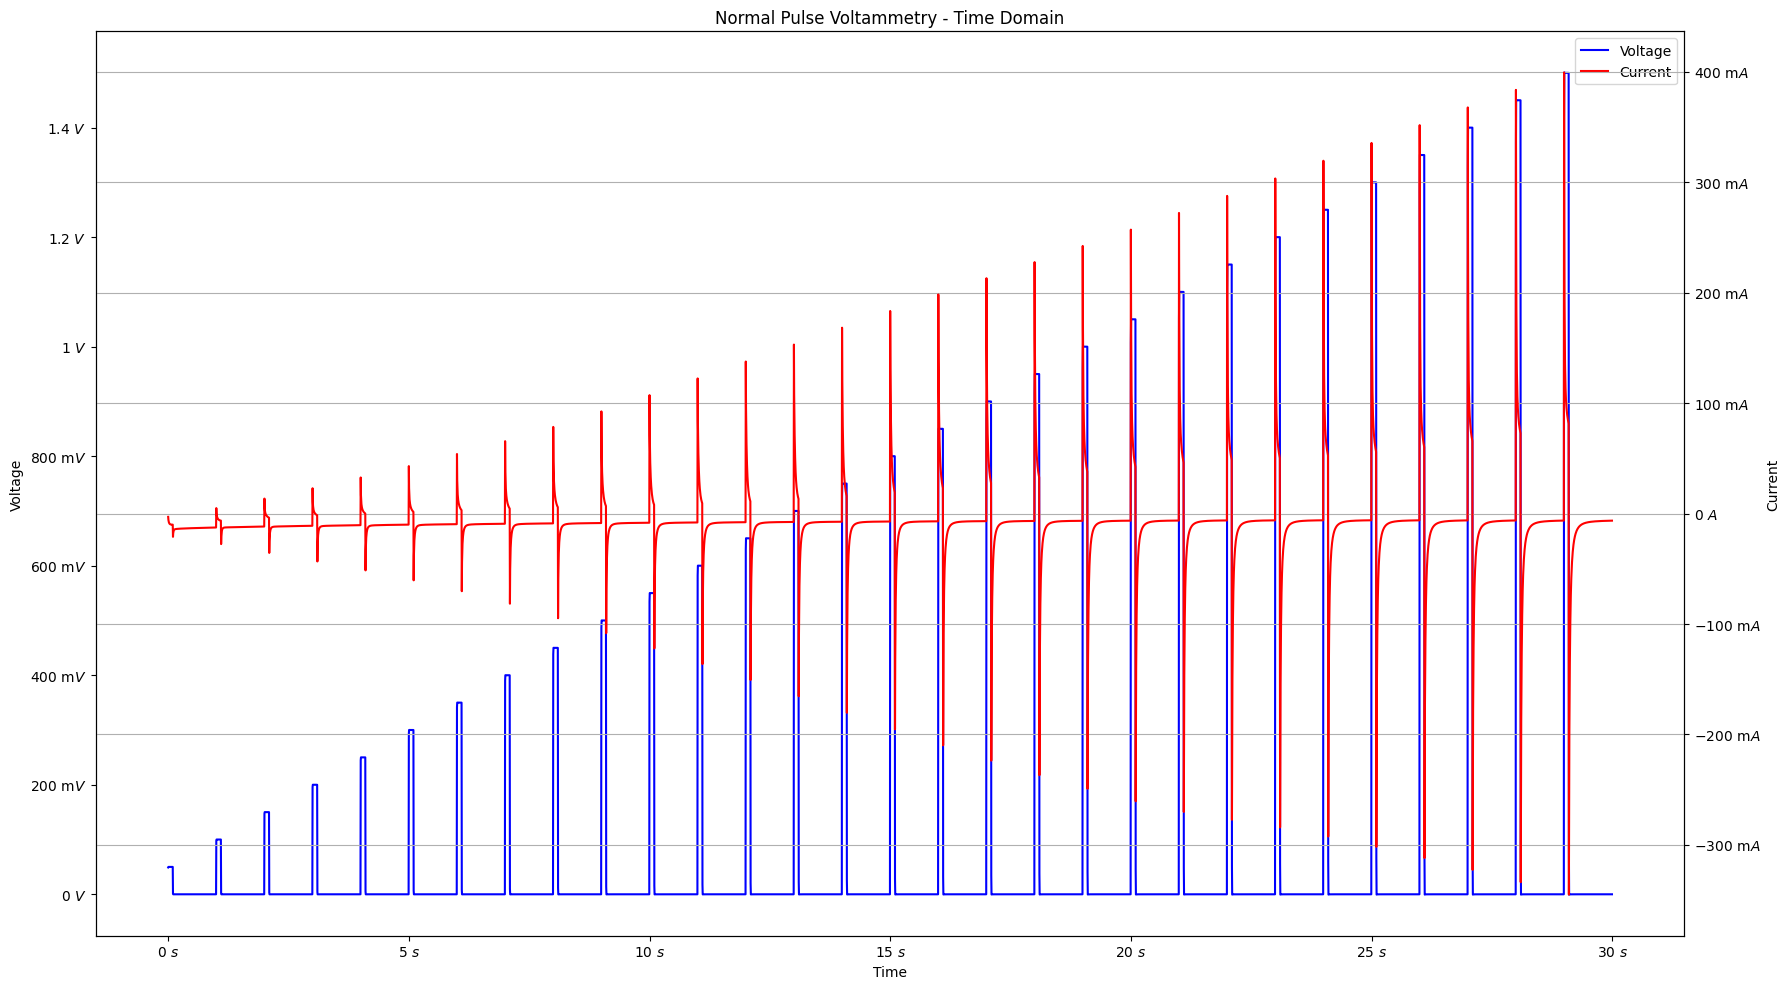

In [16]:
npv_data = load_xml("npv")
plot_dataset(npv_data, "Normal Pulse Voltammetry - Time Domain")

Next, we'll create a voltammogram (current vs. voltage plot) for our NPV data:

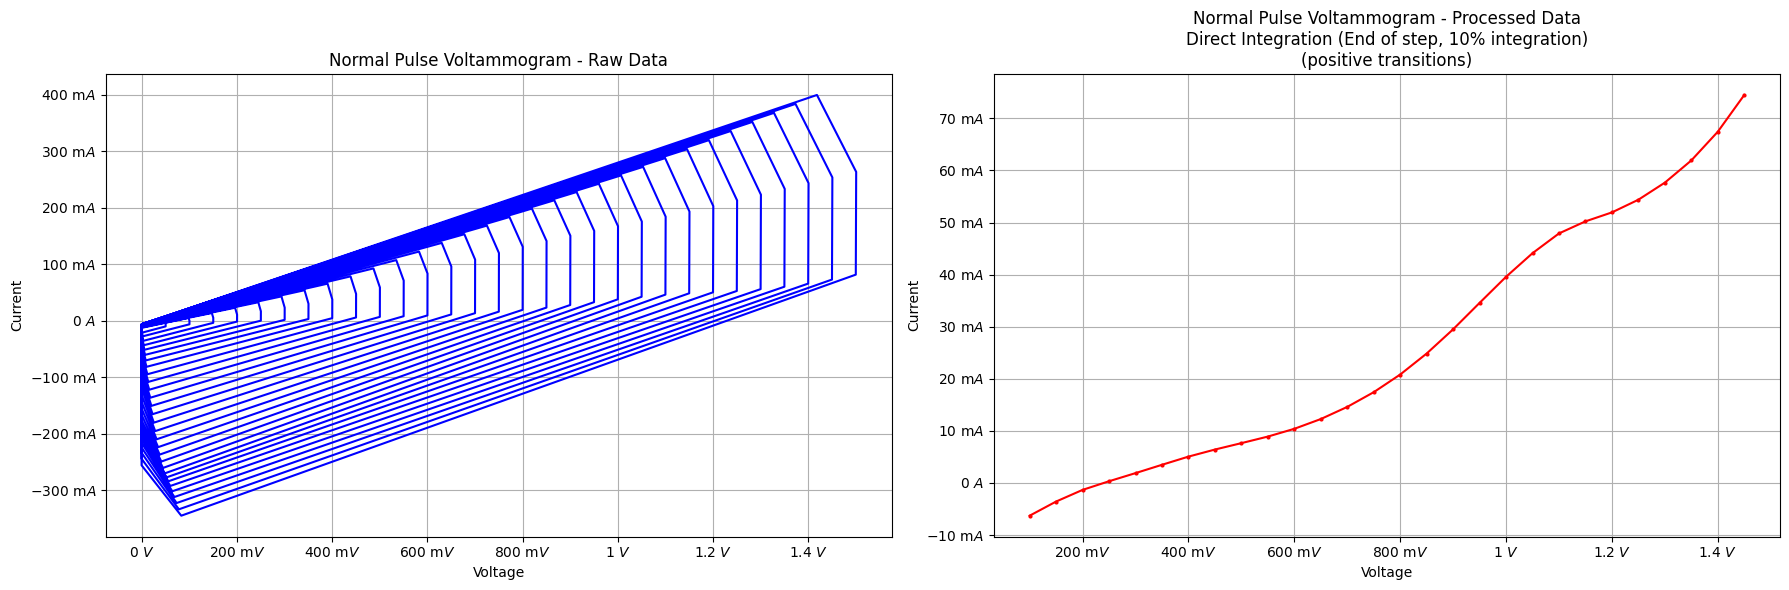

In [34]:
npv_voltage, npv_current = create_enhanced_voltammogram(
    npv_data,
    "Normal Pulse Voltammogram",
    integration_percent=10,
    voltage_threshold=step_value * 0.5,  # Adjust threshold based on step value
    transition_direction="positive",  # For NPV from 0V to negative potentials
    enable_subtraction=False,  # NPV uses direct integration, no subtraction
)

## Differential Pulse Voltammetry (DPV)

Differential Pulse Voltammetry ([DpvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.DpvJob)) applies a series of small potential pulses superimposed on a staircase potential ramp.

In [ ]:
step_value = 0.01
start_value = 0
set_bias_job.parameters.bias = start_value
link.do_job(set_bias_job)
time.sleep(2)

dpv_job = zl.meas.DpvJob(
    start_value=start_value,
    step_value=step_value,
    pulse_value=0.05,
    end_value=1.5,
    step_time=0.5,
    pulse_time=0.1,
    invert_pulse=False,
    output_data_rate=200,
    current_range=0.1,
)

print("Starting Differential Pulse Voltammetry measurement...")
link.do_job(dpv_job)
print("DPV measurement completed successfully")

dpv_data = link.get_job_result_data(dpv_job)
save_xml("dpv", dpv_data)

Starting Differential Pulse Voltammetry measurement...
DPV measurement completed successfully


Now let's visualize our DPV measurement data. First, we'll look at the time-domain representation:

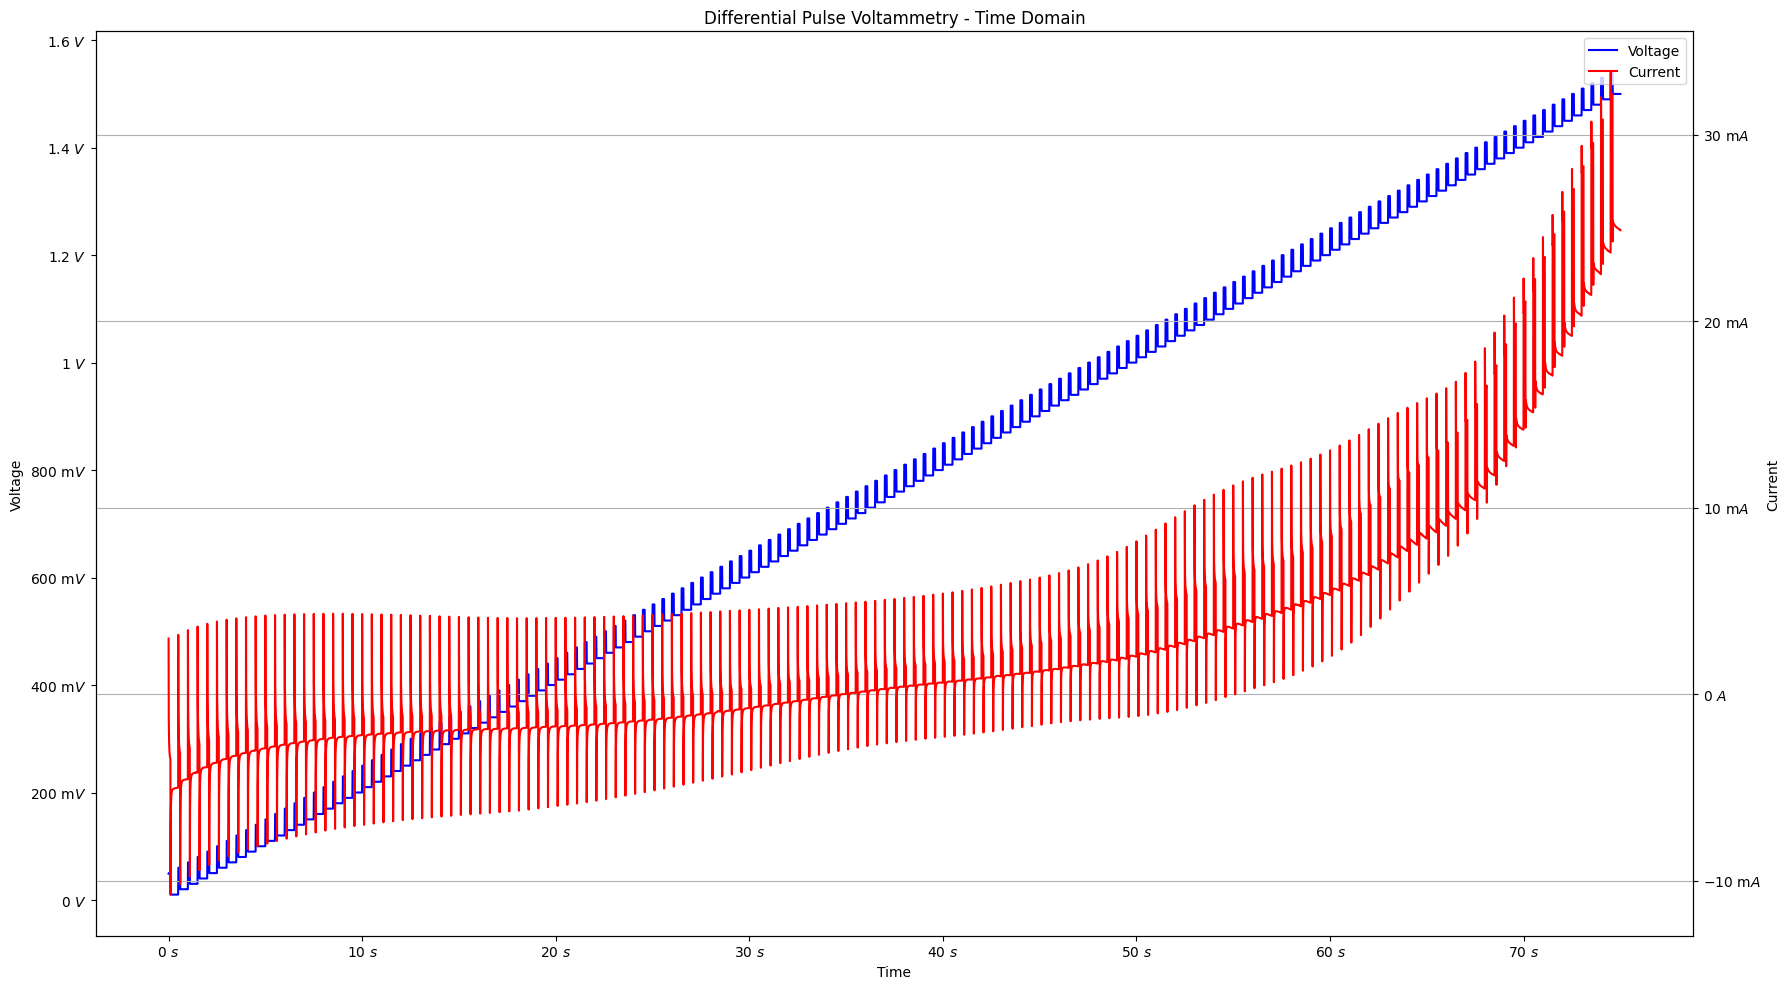

In [19]:
dpv_data = load_xml("dpv")
plot_dataset(dpv_data, "Differential Pulse Voltammetry - Time Domain")

Next, let's look at the voltammogram for our DPV measurement:

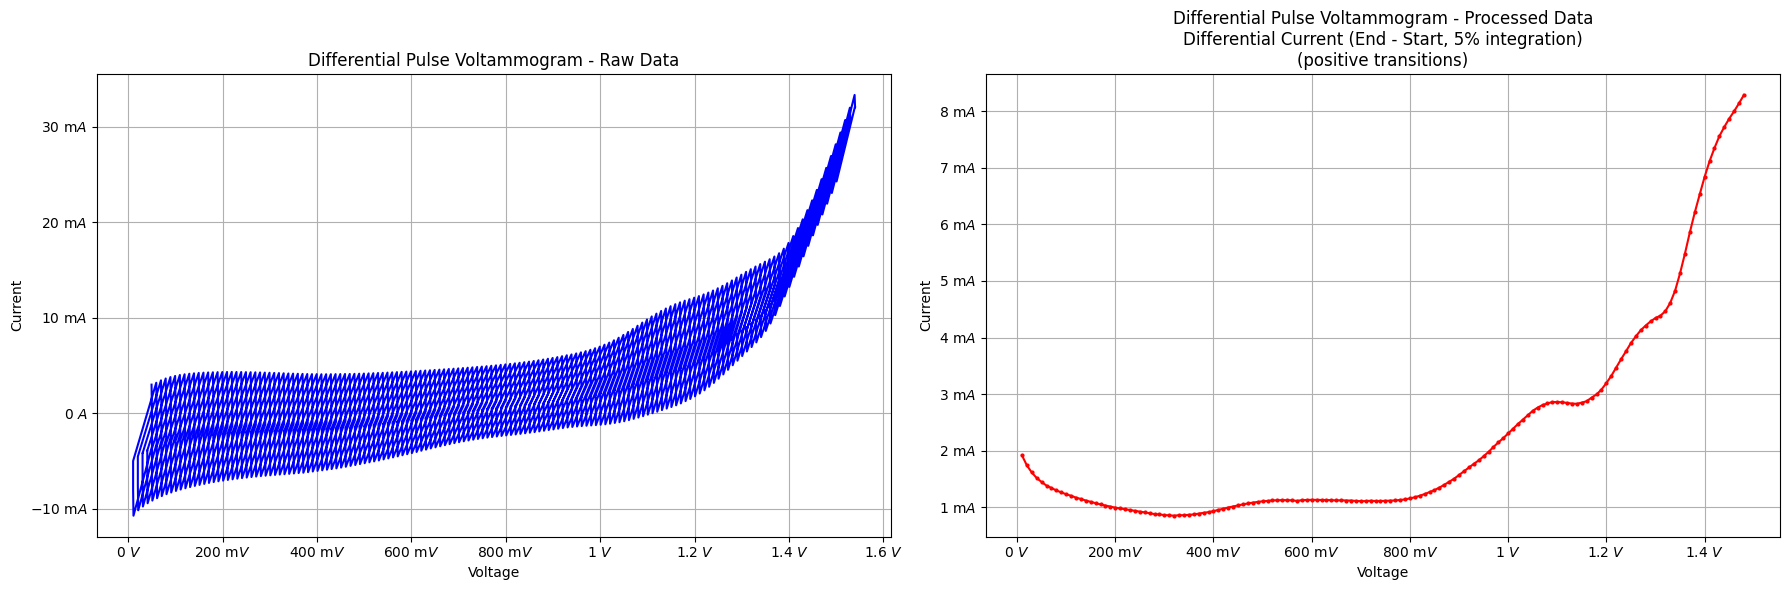

In [35]:
dpv_voltage, dpv_current = create_enhanced_voltammogram(
    dpv_data,
    "Differential Pulse Voltammogram",
    integration_percent=5,
    voltage_threshold=step_value * 0.5,  # Adjust threshold based on step value
    transition_direction="positive",  # For DPV from -1V to positive potentials
    enable_subtraction=True,  # DPV uses differential measurement (end - start)
)

## Square Wave Voltammetry (SWV)

Square Wave Voltammetry ([SwvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.SwvJob)) is one of the most sensitive pulse techniques, offering excellent discrimination against background currents and fast scan rates. It applies a square wave with forward and reverse pulses superimposed on a staircase potential.

In [21]:
amplitude = 0.05
start_value = 0
set_bias_job.parameters.bias = start_value
link.do_job(set_bias_job)
time.sleep(2)

swv_job = zl.meas.SwvJob(
    start_value=start_value,
    step_value=step_value,
    amplitude=amplitude,
    end_value=1.5,
    period=0.4,
    output_data_rate=200,
    current_range=0.1,
)

print("Starting Square Wave Voltammetry measurement...")
link.do_job(swv_job)
print("SWV measurement completed successfully")

swv_data = link.get_job_result_data(swv_job)
save_xml("swv", swv_data)

Starting Square Wave Voltammetry measurement...
SWV measurement completed successfully


Now let's visualize our SWV measurement data. First, we'll look at the time-domain representation:

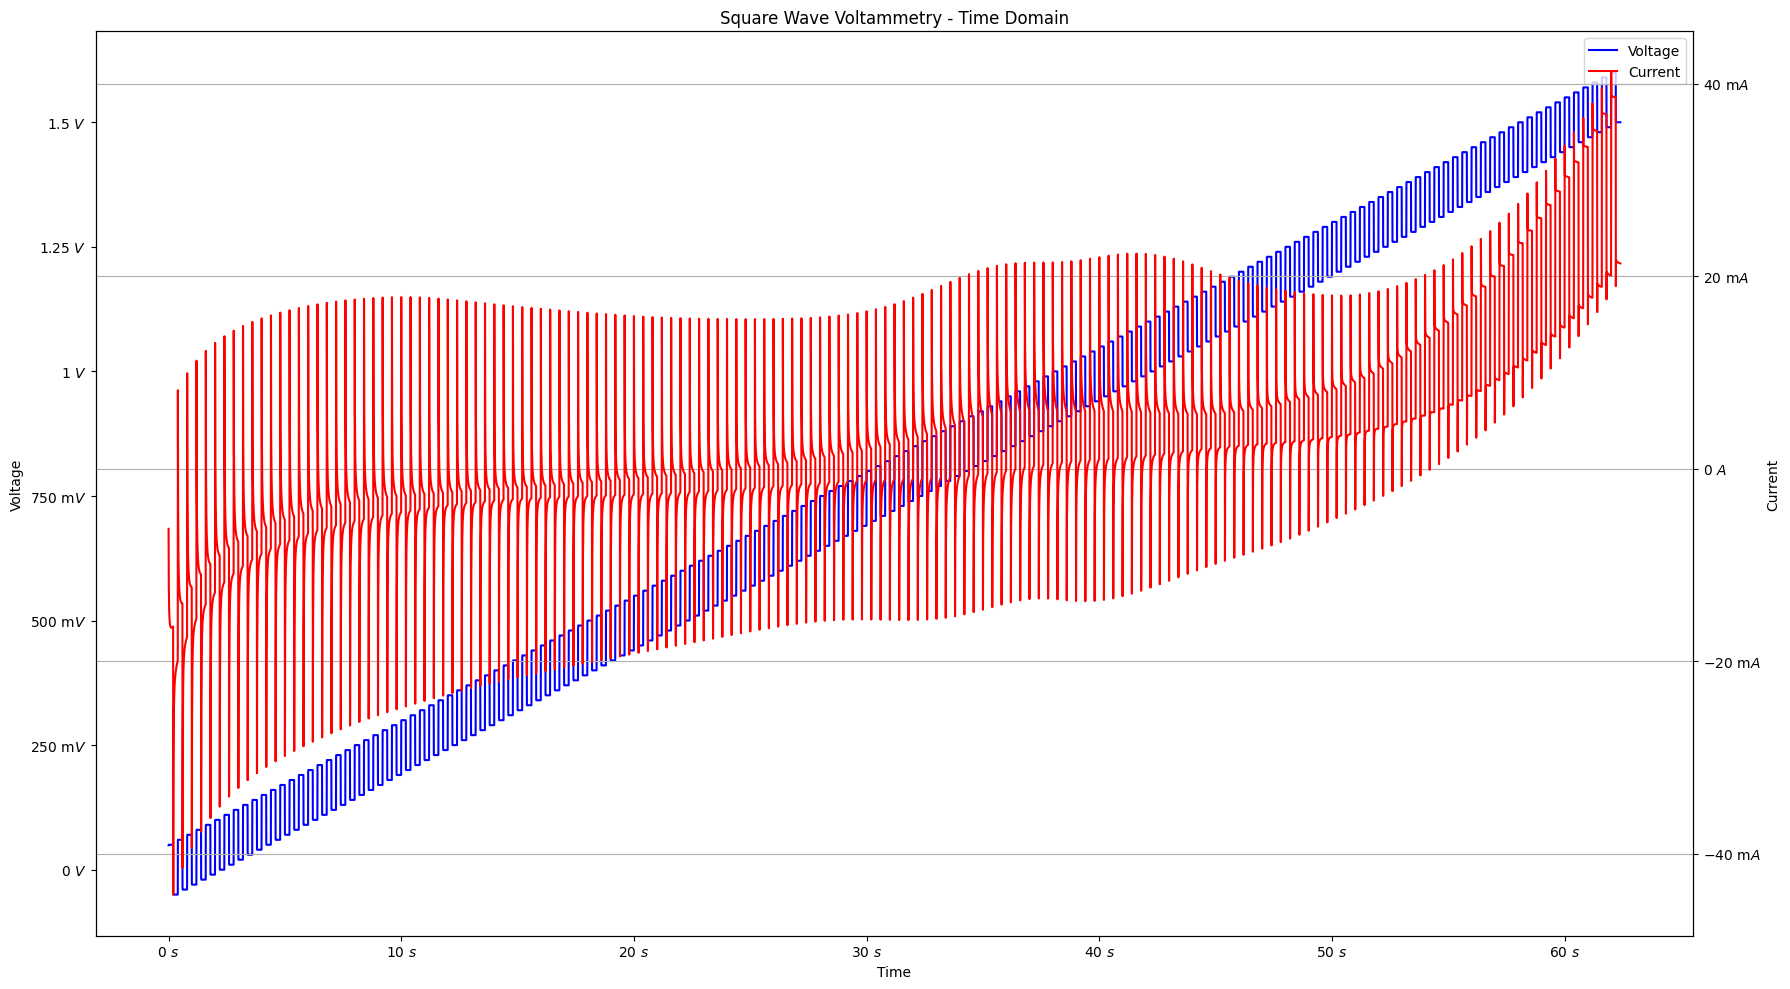

In [22]:
swv_data = load_xml("swv")
plot_dataset(swv_data, "Square Wave Voltammetry - Time Domain")

Next, let's look at the voltammogram for our SWV measurement:

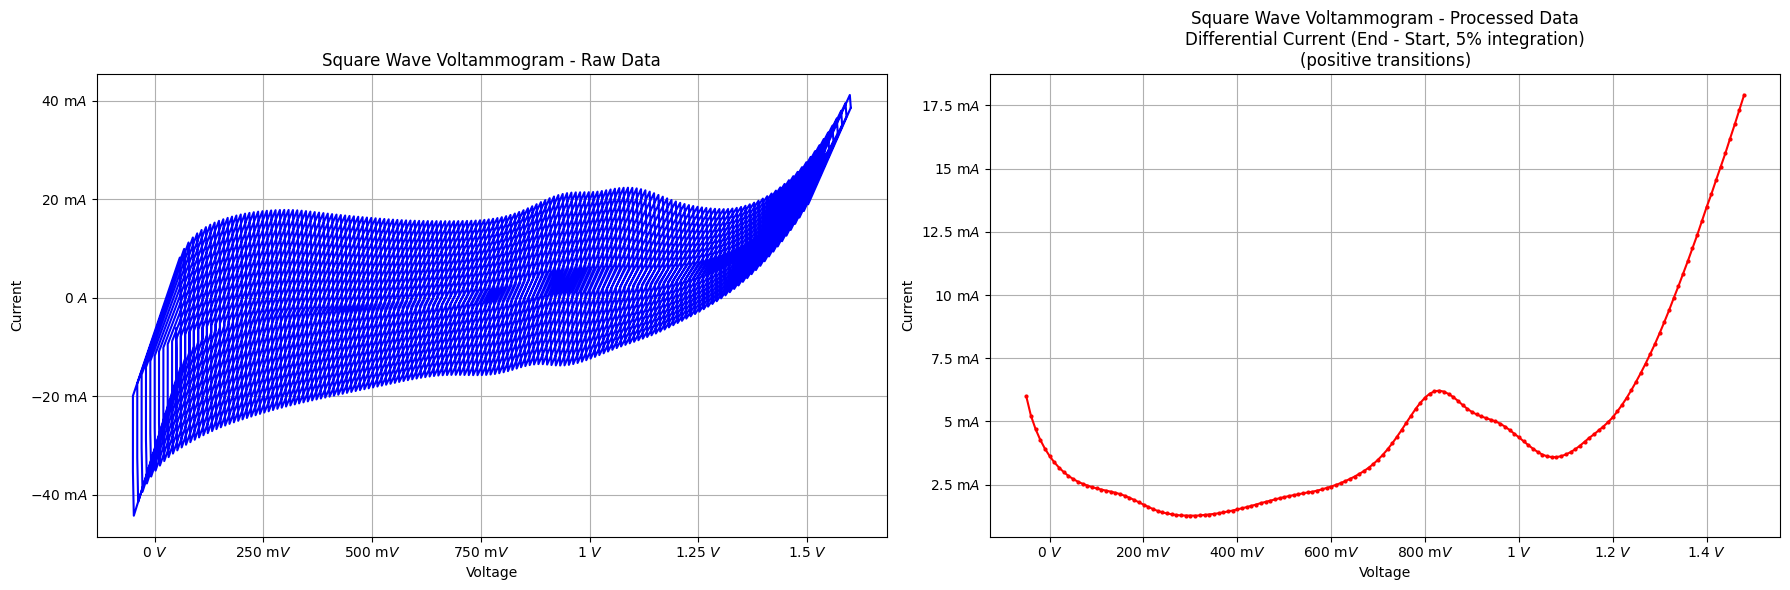

In [36]:
swv_voltage, swv_current = create_enhanced_voltammogram(
    swv_data,
    "Square Wave Voltammogram",
    integration_percent=5,
    voltage_threshold=amplitude * 0.5,  # Adjust threshold based on step value
    transition_direction="positive",  # For SWV from 0V to positive potentials
    enable_subtraction=True,  # SWV uses differential measurement (end - start)
)

Let's properly shut down the potentiostat and disconnect from the IM7.

In [24]:
link.do_job(switch_off_job)
link.disconnect()